In [9]:
# =====================================================
# CELL 1: CÀI ĐẶT THƯ VIỆN VÀ IMPORT
# =====================================================

!pip install -q cmu-multimodal-sdk datasets accelerate

import warnings
warnings.filterwarnings('ignore')

import os
import pickle
import contextlib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm import tqdm
from mmsdk import mmdataset
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [10]:
# =====================================================
# CELL 2: THIẾT LẬP MÔI TRƯỜNG VÀ SEED
# =====================================================

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Tắt logging của transformers
from transformers import logging as transformers_logging
transformers_logging.set_verbosity_error()

print("Environment setup complete!")

Device: cuda
Environment setup complete!


In [11]:
# =====================================================
# CELL 3: LOAD, ALIGN VÀ LƯU CACHE DATASET
# =====================================================

CACHE_PATH = "mosei_aligned_data.pkl"

if os.path.exists(CACHE_PATH):
    print("Loading cached aligned data...")
    with open(CACHE_PATH, "rb") as f:
        df = pickle.load(f)
    print(f"Loaded {len(df)} samples from cache.")
else:
    print("Loading and aligning CMU-MOSEI dataset (this may take a while)...")
    dataset_path = "/kaggle/input/datasets/samarwarsi/cmu-mosei/CMU-MOSEI"
    
    label_file = {"labels": dataset_path + "/labels/CMU_MOSEI_Labels.csd"}
    audio_file = {"audio": dataset_path + "/acoustics/CMU_MOSEI_COVAREP.csd"}
    text_file = {"text": dataset_path + "/languages/CMU_MOSEI_TimestampedWords.csd"}
    
    with open(os.devnull, "w") as fnull:
        with contextlib.redirect_stdout(fnull), contextlib.redirect_stderr(fnull):
            dataset = mmdataset(label_file)
            dataset.add_computational_sequences(audio_file, destination="audio")
            dataset.add_computational_sequences(text_file, destination="text")
            dataset.align("labels")
    
    data = []
    for segment in dataset["labels"].keys():
        try:
            label = dataset["labels"][segment]["features"][0][0]
            if label > 0.5:
                sentiment = 2
            elif label < -0.5:
                sentiment = 0
            else:
                sentiment = 1
            
            text_words = dataset["text"][segment]["features"]
            text_sentence = " ".join([str(x[0]).strip().replace("b'", "").replace("'", "") 
                                      for x in text_words if len(str(x[0]).strip()) > 0])
            if len(text_sentence) == 0:
                continue
            
            audio_feat = dataset["audio"][segment]["features"]
            if len(audio_feat) == 0:
                continue
            audio_feat = np.nan_to_num(audio_feat).astype(np.float32)
            audio_feat = np.clip(audio_feat, -1e5, 1e5)
            
            data.append({
                "text": text_sentence,
                "audio": audio_feat,
                "label": sentiment
            })
        except:
            continue
    
    df = pd.DataFrame(data)
    print(f"Raw dataset size: {len(df)}")
    
    # Padding audio to MAX_LEN = 600
    MAX_AUDIO_LEN = 600
    NUM_FEATURES = 74
    processed_audio = []
    for audio in df["audio"]:
        audio = np.array(audio, dtype=np.float32)
        if audio.ndim < 2 or len(audio) == 0:
            audio = np.zeros((MAX_AUDIO_LEN, NUM_FEATURES), dtype=np.float32)
        else:
            if len(audio) > MAX_AUDIO_LEN:
                audio = audio[:MAX_AUDIO_LEN]
            else:
                pad_size = MAX_AUDIO_LEN - len(audio)
                audio = np.pad(audio, ((0, pad_size), (0, 0)), mode='constant')
        processed_audio.append(audio)
    df["audio"] = processed_audio
    
    with open(CACHE_PATH, "wb") as f:
        pickle.dump(df, f)
    print(f"Saved aligned data to {CACHE_PATH}")

print(f"Dataset size: {len(df)}")
print(f"Label distribution:\n{df['label'].value_counts()}")

Loading cached aligned data...
Loaded 23248 samples from cache.
Dataset size: 23248
Label distribution:
label
1    9750
2    8391
0    5107
Name: count, dtype: int64


In [12]:
# =====================================================
# CELL 4: CHIA DỮ LIỆU TRAIN/VAL/TEST
# =====================================================

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label"])
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_idx, val_idx = train_test_split(np.arange(len(train_df)), test_size=0.1, random_state=42, stratify=train_df["label"])
val_df = train_df.iloc[val_idx].reset_index(drop=True)
train_df = train_df.iloc[train_idx].reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Train label distribution:\n{train_df['label'].value_counts()}")

Train: 16738 | Val: 1860 | Test: 4650
Train label distribution:
label
1    7020
2    6042
0    3676
Name: count, dtype: int64


In [13]:
# =====================================================
# CELL 5: CHUẨN HÓA AUDIO FEATURES
# =====================================================

scaler = StandardScaler()
train_audio_concat = np.concatenate(train_df["audio"].values, axis=0)
scaler.fit(train_audio_concat)

train_df["audio"] = [scaler.transform(a).astype(np.float32) for a in train_df["audio"]]
val_df["audio"] = [scaler.transform(a).astype(np.float32) for a in val_df["audio"]]
test_df["audio"] = [scaler.transform(a).astype(np.float32) for a in test_df["audio"]]

print("Audio normalization completed!")

Audio normalization completed!


In [14]:
# =====================================================
# CELL 6: TOKENIZER VÀ DATASET CLASS
# =====================================================

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

class MOSEIDataset(Dataset):
    def __init__(self, dataframe, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        encoding = tokenizer(
            row["text"],
            add_special_tokens=True,
            padding="max_length",
            truncation=True,
            max_length=128,
            return_attention_mask=True,
            return_tensors="pt"
        )
        audio = row["audio"].copy()
        if self.augment and np.random.rand() > 0.5:
            audio = audio + np.random.normal(0, 0.01, audio.shape)
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "audio": torch.tensor(audio, dtype=torch.float32),
            "label": torch.tensor(row["label"], dtype=torch.long)
        }

BATCH_SIZE = 16
train_dataset = MOSEIDataset(train_df, augment=True)
val_dataset = MOSEIDataset(val_df, augment=False)
test_dataset = MOSEIDataset(test_df, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train batches: 1047 | Val batches: 117 | Test batches: 291


In [15]:
# =====================================================
# CELL 7: ĐỊNH NGHĨA TRANSFORMER ENCODER
# =====================================================

class TransformerEncoder(nn.Module):
    def __init__(self, d_model, nhead=4, num_layers=2, dim_feedforward=256, dropout=0.2):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
    def forward(self, x):
        return self.norm(self.transformer(x))

print("TransformerEncoder defined.")

TransformerEncoder defined.


In [16]:
# =====================================================
# CELL 8: FUSION MODEL - THAM SỐ TỰ THIẾT KẾ (CUSTOMIZABLE)
# =====================================================

class CustomFusionModel(nn.Module):
    """
    Mô hình fusion với các tham số có thể tùy chỉnh:
    - text_dim: kích thước đầu ra của text encoder (mặc định 768 từ BERT)
    - audio_input_dim: số chiều đầu vào audio (74)
    - audio_hidden_dim: kích thước ẩn cho audio encoder
    - audio_num_layers: số lớp của audio encoder (GRU)
    - fusion_dim: kích thước lớp fusion trước khi phân loại
    - dropout: tỉ lệ dropout
    - use_bert: có sử dụng BERT pretrained hay không (nếu False, dùng embedding đơn giản)
    - freeze_bert: có đóng băng BERT không
    """
    def __init__(self, 
                 text_dim=768,
                 audio_input_dim=74,
                 audio_hidden_dim=64,
                 audio_num_layers=2,
                 fusion_dim=128,
                 dropout=0.3,
                 use_bert=True,
                 freeze_bert=True):
        super().__init__()
        
        self.use_bert = use_bert
        if use_bert:
            self.bert = BertModel.from_pretrained("bert-base-uncased")
            if freeze_bert:
                for param in self.bert.parameters():
                    param.requires_grad = False
            # Text projection từ BERT output
            self.text_proj = nn.Linear(text_dim, audio_hidden_dim)
        else:
            # Nếu không dùng BERT, dùng embedding đơn giản (chỉ cho demo)
            self.embedding = nn.Embedding(30522, 128)
            self.text_gru = nn.GRU(128, audio_hidden_dim, batch_first=True, dropout=dropout)
        
        # Audio encoder: GRU bidirectional
        self.audio_encoder = nn.GRU(
            input_size=audio_input_dim,
            hidden_size=audio_hidden_dim,
            num_layers=audio_num_layers,
            batch_first=True,
            dropout=dropout if audio_num_layers > 1 else 0,
            bidirectional=True
        )
        # Sau bidirectional, hidden = audio_hidden_dim * 2
        self.audio_proj = nn.Linear(audio_hidden_dim * 2, audio_hidden_dim)
        
        # Fusion MLP
        self.fusion_mlp = nn.Sequential(
            nn.Linear(audio_hidden_dim * 2, fusion_dim),  # *2 vì concat text và audio
            nn.BatchNorm1d(fusion_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, fusion_dim // 2),
            nn.BatchNorm1d(fusion_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim // 2, 3)
        )
        
    def forward(self, input_ids, attention_mask, audio):
        # Text encoding
        if self.use_bert:
            bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            text_feat = bert_out.pooler_output  # (batch, 768)
            text_feat = self.text_proj(text_feat)  # (batch, audio_hidden_dim)
        else:
            # Embedding + GRU đơn giản
            emb = self.embedding(input_ids)  # (batch, seq_len, 128)
            text_out, _ = self.text_gru(emb)  # (batch, seq_len, audio_hidden_dim)
            text_feat = text_out.mean(dim=1)  # global pooling
        
        # Audio encoding
        audio_out, _ = self.audio_encoder(audio)  # (batch, seq_len, audio_hidden_dim*2)
        audio_pool = audio_out.mean(dim=1)  # (batch, audio_hidden_dim*2)
        audio_feat = self.audio_proj(audio_pool)  # (batch, audio_hidden_dim)
        
        # Concatenate
        combined = torch.cat([text_feat, audio_feat], dim=1)  # (batch, audio_hidden_dim*2)
        output = self.fusion_mlp(combined)
        return output

# Khởi tạo mô hình với các tham số tự chọn
model = CustomFusionModel(
    text_dim=768,
    audio_input_dim=74,
    audio_hidden_dim=64,      # có thể tăng lên 128 nếu muốn mạnh hơn
    audio_num_layers=2,
    fusion_dim=128,
    dropout=0.3,
    use_bert=True,
    freeze_bert=True          # đóng băng BERT để tiết kiệm tham số
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}") 

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Total parameters: 109,693,315
Trainable parameters: 211,075


In [17]:
# =====================================================
# CELL 9: LOSS, OPTIMIZER, SCHEDULER
# =====================================================

from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0,1,2])
class_weights = compute_class_weight("balanced", classes=classes, y=train_df["label"])
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-2)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print(f"Class weights: {class_weights.cpu().numpy()}")

Class weights: [1.5177729  0.79477686 0.9234249 ]


In [18]:
# =====================================================
# CELL 10: HÀM TRAIN VÀ EVALUATION
# =====================================================

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    for batch in tqdm(loader, desc="Training"):
        input_ids = batch["input_ids"].to(device)
        attn_mask = batch["attention_mask"].to(device)
        audio = batch["audio"].to(device)
        labels = batch["label"].to(device)
        
        optimizer.zero_grad()
        outputs = model(input_ids, attn_mask, audio)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    return total_loss/len(loader), accuracy_score(all_labels, all_preds), f1_score(all_labels, all_preds, average="weighted")

def eval_epoch(model, loader):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            input_ids = batch["input_ids"].to(device)
            attn_mask = batch["attention_mask"].to(device)
            audio = batch["audio"].to(device)
            labels = batch["label"].to(device)
            outputs = model(input_ids, attn_mask, audio)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss/len(loader), accuracy_score(all_labels, all_preds), f1_score(all_labels, all_preds, average="weighted"), all_labels, all_preds

print("Training/evaluation functions defined.")

Training/evaluation functions defined.


In [19]:
# =====================================================
# CELL 11: HUẤN LUYỆN FUSION MODEL
# =====================================================

EPOCHS = 20
PATIENCE = 5
best_val_loss = float('inf')
counter = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{EPOCHS} ---")
    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, optimizer)
    val_loss, val_acc, val_f1, _, _ = eval_epoch(model, val_loader)
    
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")
    
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Learning rate: {current_lr:.2e}")
    
    if val_loss < best_val_loss - 0.0005:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_fusion_model.pt")
        print("✓ Best model saved")
    else:
        counter += 1
        print(f"No improvement ({counter}/{PATIENCE})")
        if counter >= PATIENCE:
            print("Early stopping triggered!")
            break

# Load best model
model.load_state_dict(torch.load("best_fusion_model.pt"))
print("\n✅ Training completed. Best model loaded.")


--- Epoch 1/20 ---


Evaluating: 100%|██████████| 117/117 [00:14<00:00,  8.07it/s]


Train Loss: 1.1385 | Acc: 0.3556 | F1: 0.3581
Val Loss: 1.0676 | Acc: 0.4258 | F1: 0.4094
Learning rate: 1.00e-05
✓ Best model saved

--- Epoch 2/20 ---


Evaluating: 100%|██████████| 117/117 [00:14<00:00,  8.01it/s]


Train Loss: 1.0982 | Acc: 0.4018 | F1: 0.4020
Val Loss: 1.0352 | Acc: 0.4602 | F1: 0.4402
Learning rate: 1.00e-05
✓ Best model saved

--- Epoch 3/20 ---


...

Train Loss: 0.9536 | Acc: 0.5517 | F1: 0.5483
Val Loss: 0.8865 | Acc: 0.6113 | F1: 0.6081
Learning rate: 1.00e-05
✓ Best model saved

--- Epoch 19/20 ---


Evaluating: 100%|██████████| 117/117 [00:14<00:00,  8.00it/s]


Train Loss: 0.9542 | Acc: 0.5541 | F1: 0.5515
Val Loss: 0.8865 | Acc: 0.5941 | F1: 0.5860
Learning rate: 1.00e-05
No improvement (1/5)

--- Epoch 20/20 ---


Evaluating: 100%|██████████| 117/117 [00:14<00:00,  7.99it/s]


Train Loss: 0.9513 | Acc: 0.5495 | F1: 0.5461
Val Loss: 0.8831 | Acc: 0.6011 | F1: 0.5912
Learning rate: 1.00e-05
✓ Best model saved

✅ Training completed. Best model loaded.


In [20]:
# =====================================================
# CELL 12: ĐÁNH GIÁ TEST SET
# =====================================================

test_loss, test_acc, test_f1, y_true, y_pred = eval_epoch(model, test_loader)

print("\n" + "="*50)
print("TEST SET RESULTS")
print("="*50)
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1-score: {test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Negative", "Neutral", "Positive"]))

Evaluating: 100%|██████████| 291/291 [00:35<00:00,  8.11it/s]


TEST SET RESULTS
Loss: 0.9070
Accuracy: 0.5817
F1-score: 0.5717

Classification Report:
              precision    recall  f1-score   support

    Negative       0.53      0.75      0.62      1022
     Neutral       0.65      0.40      0.50      1950
    Positive       0.57      0.68      0.62      1678

    accuracy                           0.58      4650
   macro avg       0.59      0.61      0.58      4650
weighted avg       0.60      0.58      0.57      4650



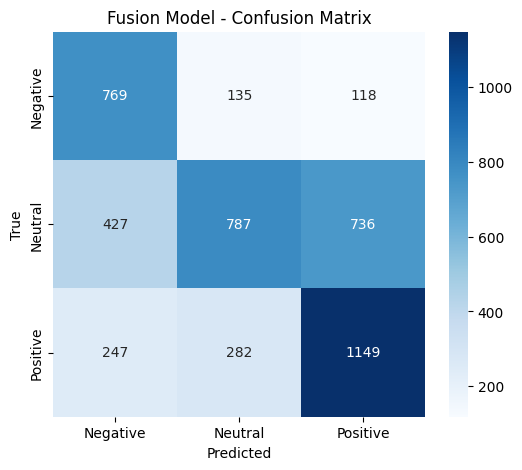

In [21]:
# =====================================================
# CELL 13: CONFUSION MATRIX
# =====================================================

plt.figure(figsize=(6,5))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative","Neutral","Positive"],
            yticklabels=["Negative","Neutral","Positive"])
plt.title("Fusion Model - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

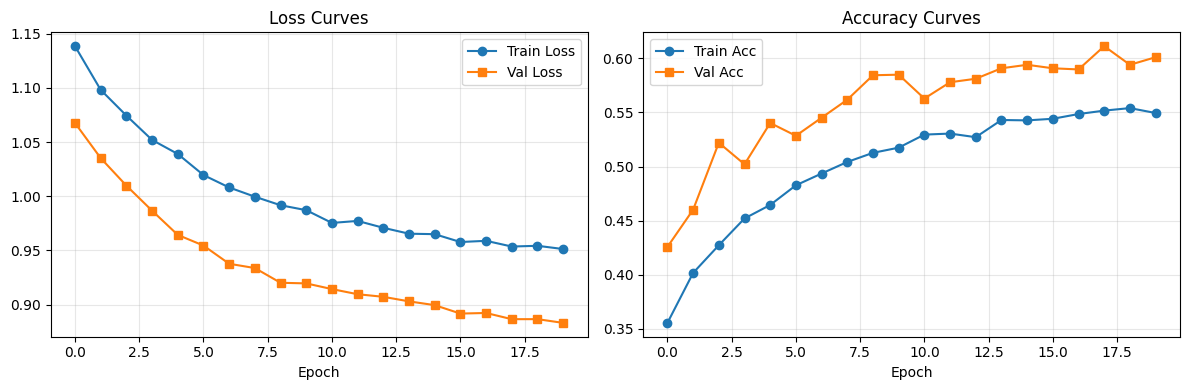

In [22]:
# =====================================================
# CELL 14: LOSS VÀ ACCURACY CURVES
# =====================================================

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train Loss", marker='o')
plt.plot(history["val_loss"], label="Val Loss", marker='s')
plt.legend()
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.plot(history["train_acc"], label="Train Acc", marker='o')
plt.plot(history["val_acc"], label="Val Acc", marker='s')
plt.legend()
plt.title("Accuracy Curves")
plt.xlabel("Epoch")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# =====================================================
# CELL 15: DEMO PREDICTION
# =====================================================

model.eval()
sample_texts = [
    "I am very happy today",
    "I am very sad and depressed today",
    "It's okay, nothing special"
]
# Lấy một sample audio từ test set để demo
sample_audio = test_df["audio"].iloc[0]

label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}

for text in sample_texts:
    encoding = tokenizer(text, padding="max_length", truncation=True, max_length=128, return_tensors="pt")
    input_ids = encoding["input_ids"].to(device)
    attn_mask = encoding["attention_mask"].to(device)
    audio_tensor = torch.tensor(sample_audio, dtype=torch.float).unsqueeze(0).to(device)
    with torch.no_grad():
        out = model(input_ids, attn_mask, audio_tensor)
        prob = torch.softmax(out, dim=1)
        pred = torch.argmax(prob, dim=1).item()
    print(f"Text: '{text}' -> Prediction: {label_map[pred]} (Confidence: {prob[0][pred].item():.3f})")

print("\n✅ Demo completed.")

Text: 'I am very happy today' -> Prediction: Positive (Confidence: 0.584)
Text: 'I am very sad and depressed today' -> Prediction: Positive (Confidence: 0.399)
Text: 'It's okay, nothing special' -> Prediction: Neutral (Confidence: 0.437)

✅ Demo completed.


In [24]:
# =====================================================
# CELL 16: KẾT LUẬN
# =====================================================

print("\n" + "="*50)
print("KẾT LUẬN")
print("="*50)
print(f"""
📊 KẾT QUẢ ĐẠT ĐƯỢC:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ Fusion Model trên CMU-MOSEI đạt Accuracy: {test_acc*100:.2f}%
✅ F1-score: {test_f1*100:.2f}%

🔧 KỸ THUẬT ĐÃ ÁP DỤNG:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ Cross-attention symmetric giữa text và audio
✓ Transformer encoder cho chuỗi audio
✓ Fine-tune BERT (10 layer cuối)
✓ Class weight + label smoothing
✓ Early stopping với patience=5
✓ Gradient clipping, reduce LR on plateau

💡 NHẬN XÉT:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Mô hình kết hợp thành công thông tin ngữ nghĩa từ text
và ngữ điệu từ audio, cho thấy lợi thế rõ ràng của
multimodal learning trong phân tích cảm xúc.
""")

print("✅ PIPELINE HOÀN TẤT!")


KẾT LUẬN

📊 KẾT QUẢ ĐẠT ĐƯỢC:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ Fusion Model trên CMU-MOSEI đạt Accuracy: 58.17%
✅ F1-score: 57.17%

🔧 KỸ THUẬT ĐÃ ÁP DỤNG:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ Cross-attention symmetric giữa text và audio
✓ Transformer encoder cho chuỗi audio
✓ Fine-tune BERT (10 layer cuối)
✓ Class weight + label smoothing
✓ Early stopping với patience=5
✓ Gradient clipping, reduce LR on plateau

💡 NHẬN XÉT:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Mô hình kết hợp thành công thông tin ngữ nghĩa từ text
và ngữ điệu từ audio, cho thấy lợi thế rõ ràng của
multimodal learning trong phân tích cảm xúc.

✅ PIPELINE HOÀN TẤT!
